In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [10]:
# # NOT NEEDED CURRENTLY
# #Job Array 

# num_jobs=30 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
# #limited by num_parcels

# job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
# if job_id==0: job_id=1
# num_parcels=len(data['time']) #total number of parcels
# job_range = num_parcels//num_jobs #number of parcels per job 

# # Calculate start and end based on job_id
# start_job = (job_id - 1) * job_range
# end_job = start_job + job_range
# if job_id==num_jobs: end_job=num_parcels-1
# print(f'running for times {start_job}-{end_job}')

# data=data.isel(time=slice(start_job,end_job))
# parcel=parcel.isel(time=slice(start_job,end_job))

In [ ]:
##########################################################################################
#Functions
# Full Profile function makes profile together for all timesteps. AveragedProfiles funciton takes the final mean of the combined profile.

In [3]:
#Making vertical profile of cloudy updrafts
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    print('done loading')
    emptylike=True


def final_profile(var,type):
    global w_thresh
    #thresholds
    w_thresh=1
    qcqithresh=1e-6

    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #gets data associated with threshold mask
    if var=='w':
        masked_data=w_data[where_updraft]
    if var=='qv':
        masked_data=qv_data[where_updraft]
    if var=='qc':
        masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
    if var=='qi':
        masked_data=qi_data[where_updraft]
    if var=='th':
        masked_data=th_data[where_updraft]
    if var=='buoyancy':
        masked_data=buoyancy_data[where_updraft]
        
    #converts qv and qc from kg/kg=>g/kg
    if var in ['qv','qc','qi']:
        masked_data*=1000

    #bin masked values by z level
    for (kh,value) in zip(z_ind,masked_data):
        profile_array[kh,0]+=value #adds data to first column
        profile_array[kh,1]+=1 #adds +1 counter to 2nd column
    return profile_array

loading neccessary variables
done loading


In [18]:
# #Making vertical CTRL profile of cloudy updrafts

# def CTRL_final_profile(var,type):
#     global w_thresh
#     #thresholds
#     w_thresh=1
#     qcqithresh=1e-6

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data<w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data<w_thresh) | (qc_plus_qi<qcqithresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft

#     #gets data associated with threshold mask
#     if var=='w':
#         masked_data=w_data[where_updraft]
#     if var=='qv':
#         masked_data=qv_data[where_updraft]
#     if var=='qc':
#         masked_data=qc_plus_qi[where_updraft]
#     if var=='qi':
#         masked_data=qi_data[where_updraft]
#     if var=='th':
#         masked_data=th_data[where_updraft]
#     if var=='buoyancy':
#         masked_data=buoyancy_data[where_updraft]
        
#     #converts qv and qc from kg/kg=>g/kg
#     if var in ['qv','qc','qi']:
#         masked_data*=1000

#     #bin masked values by z level
#     for (kh,value) in zip(z_ind,masked_data):
#         profile_array[kh,0]+=value #adds data to first column
#         profile_array[kh,1]+=1 #adds +1 counter to 2nd column
#     return profile_array


In [ ]:
##########################################################################################
#Running (Only Run Once)

In [4]:
#Final_Profile Function
w_thresh=1

yes_run=False
yes_run=True #uncomment if running

if yes_run==True: 
    dim='1km' 
    # dim='250m'
    
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        
        vars=['w','qv','qc','qi','th','buoyancy']
        # vars=['qc','th'] #TESTING***
        for var in vars:
            print(f'working on {var}')
            globals()[f"profile_{var}"]=final_profile(var,type)
        print('done')
        
        #Saving eulerian_profiles
        import h5py
        if dim=='1km':
            if type == "general":
                output_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_wthresh{w_thresh}.h5' 
            elif type == "cloudy":
                output_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_wthresh{w_thresh}.h5'
        
        if dim=='250m':
            if type == "general":
                output_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_wthresh{w_thresh}.h5' 
            elif type == "cloudy":
                output_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_wthresh{w_thresh}.h5' 
        
        with h5py.File(output_file, 'w') as f:
            f.create_dataset('profile_w', data=profile_w, compression="gzip")
            f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
            f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
            f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
            f.create_dataset('profile_th', data=profile_th, compression="gzip")
            f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")

currently on type general
working on w
working on qv
working on qc
working on qi
working on th
working on buoyancy
done
currently on type cloudy
working on w
working on qv
working on qc
working on qi
working on th
working on buoyancy
done


In [19]:
# #CTRL_Final_Profile Function

# yes_run=False
# yes_run=True #uncomment if running

# if yes_run==True: 
#     dim='1km' 
#     # dim='250m'
    
#     for type in ["general","cloudy"]:
#         print(f'currently on type {type}')
        
#         vars=['w','qv','qc','qi','th','buoyancy']
#         # vars=['qc','th'] #TESTING***
#         for var in vars:
#             print(f'working on {var}')
#             globals()[f"profile_{var}"]=CTRL_final_profile(var,type)
#         print('done')
        
#         #Saving eulerian_profiles
#         import h5py
#         if dim=='1km':
#             if type == "general":
#                 output_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
#             elif type == "cloudy":
#                 output_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
        
#         if dim=='250m':
#             if type == "general":
#                 output_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
#             elif type == "cloudy":
#                 output_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
        
#         with h5py.File(output_file, 'w') as f:
#             f.create_dataset('profile_w', data=profile_w, compression="gzip")
#             f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
#             f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
#             f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
#             f.create_dataset('profile_th', data=profile_th, compression="gzip")
#             f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")

currently on type general
working on w
working on qv
working on qc
working on qi
working on th
working on buoyancy
done
currently on type cloudy
working on w
working on qv
working on qc
working on qi
working on th
working on buoyancy
done


In [ ]:
##########################################################################################
#Plotting

currently on type general
currently on type cloudy


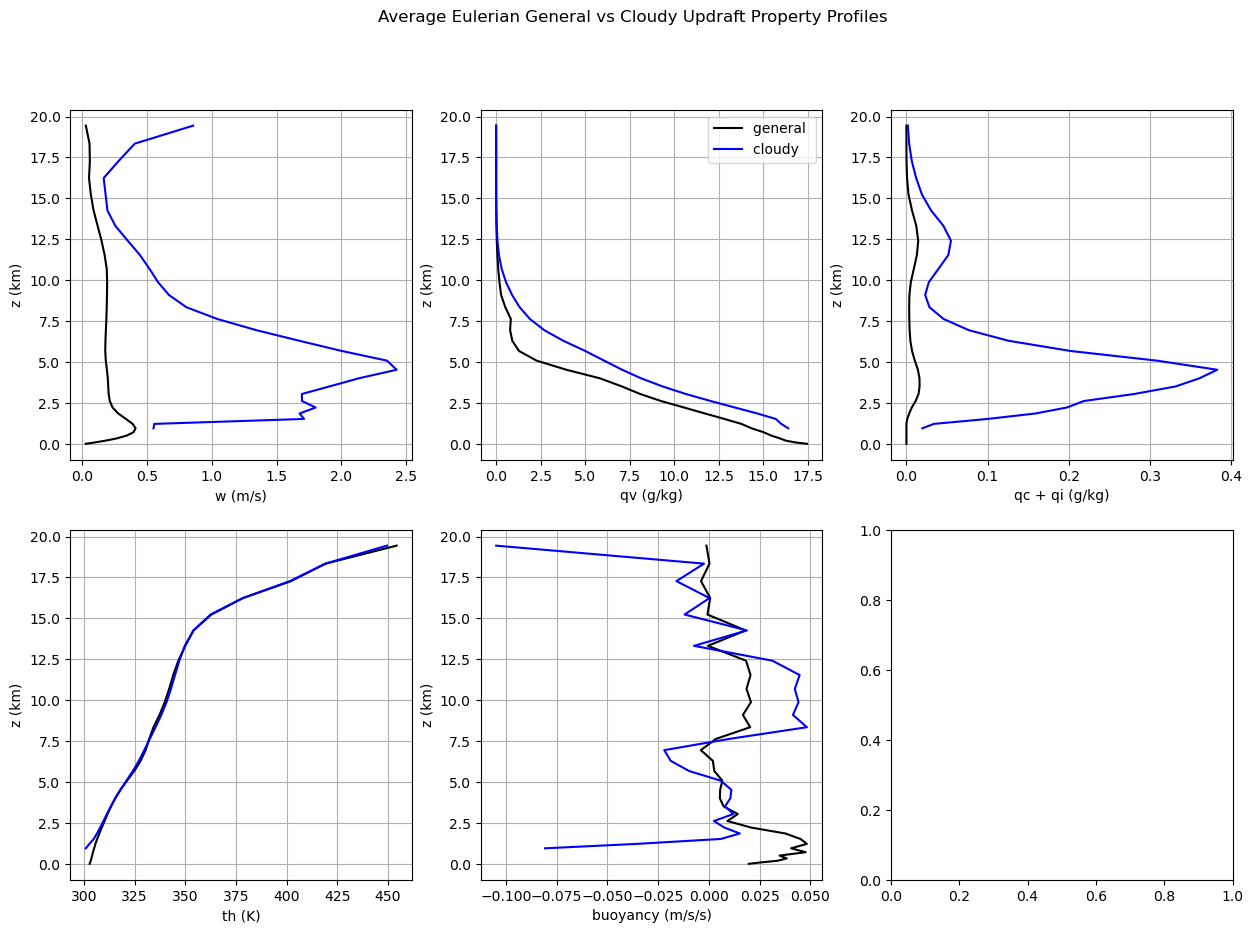

In [9]:
import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'
# dim='250m'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# if type=='general':
#     fig.suptitle(f"average eulerian updraft property profiles") 
# if type=='cloudy':
#     fig.suptitle(f"average eulerian cloudy updraft property profiles")
fig.suptitle(f"Average Eulerian General vs Cloudy Updraft Property Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
# plt.tight_layout()

####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_wthresh{w_thresh}.h5'
            # input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_wthresh{w_thresh}.h5' 
            # input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
    
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_wthresh{w_thresh}.h5' 
            # input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_wthresh{w_thresh}.h5' 
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_buoyancy = np.array(f['profile_buoyancy'])

    #adding qc and qi profile together
    profile_qc[:,0]+=profile_qi[:,0] #for qi
    profile_qc[:,1]+=profile_qi[:,1] #for qi
    
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars=['w','qv','qc','th','buoyancy'] #qi
    # vars=['w'] #TESTING
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    
    vars=['w','qv','qc','th','buoyancy'] 
    # vars=['w'] #TESTING
    axises=[ax1,ax2,ax3,ax4,ax5] #ax5
    xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'
        plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

        if axis==ax2:
            axis.legend(); #add legend

#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 
    # plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}jpg', bbox_inches='tight', dpi=300)
elif dim=='250m':
    plt.savefig(dir+f'tracking_algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 
    # plt.savefig(dir+f'tracking_algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}jpg', bbox_inches='tight', dpi=300)

currently on type general
currently on type cloudy


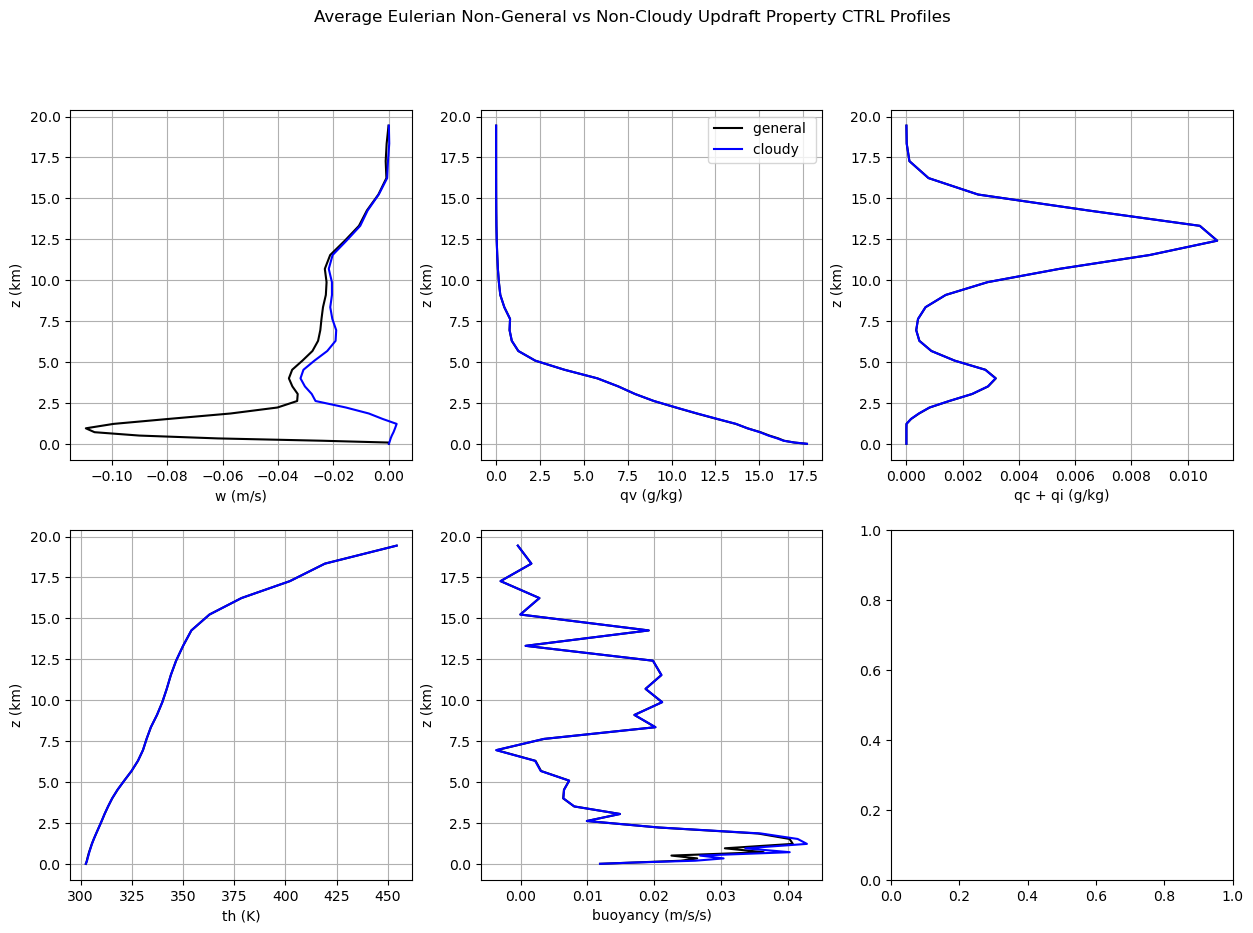

In [30]:
import h5py
#Produced averaged CTRL profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'
# dim='250m'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# if type=='general':
#     fig.suptitle(f"average eulerian updraft property profiles") 
# if type=='cloudy':
#     fig.suptitle(f"average eulerian cloudy updraft property profiles")
fig.suptitle(f"Average Eulerian Non-General vs Non-Cloudy Updraft Property CTRL Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
# plt.tight_layout()

####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
    
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_buoyancy = np.array(f['profile_buoyancy'])

    #adding qc and qi profile together
    profile_qc[:,0]+=profile_qi[:,0] #for qi
    profile_qc[:,1]+=profile_qi[:,1] #for qi
    
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars=['w','qv','qc','th','buoyancy'] #qi
    # vars=['w'] #TESTING
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    
    vars=['w','qv','qc','th','buoyancy'] 
    # vars=['w'] #TESTING
    axises=[ax1,ax2,ax3,ax4,ax5] #ax5
    xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'
        plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

        if axis==ax2:
            axis.legend(); #add legend

#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}jpg', bbox_inches='tight', dpi=300)
elif dim=='250m':
    plt.savefig(dir+f'tracking_algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 

currently on type general
currently on type cloudy


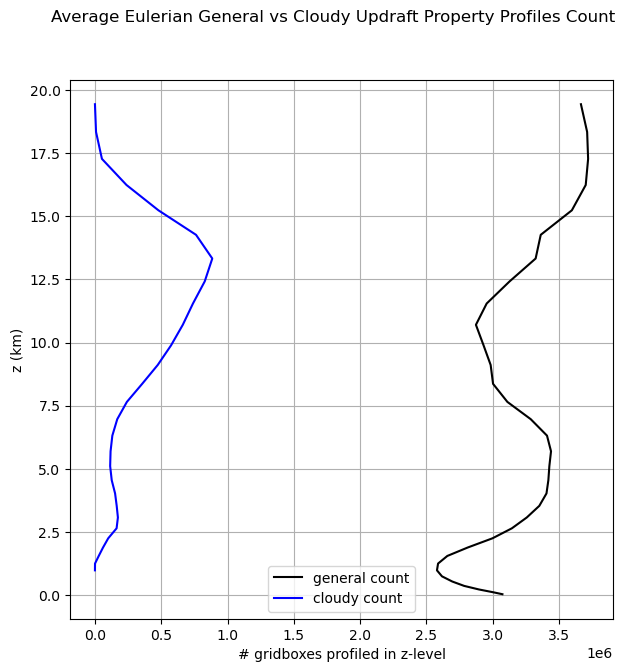

In [11]:
#Plotting counter column
dim='1km'
# dim='250m'

#Uses CounterPlotting Function
fig, axs = plt.subplots(1,1, figsize=(7,7))
fig.suptitle(f"Average Eulerian General vs Cloudy Updraft Property Profiles Count") #uncomment if "general updrafts"
# fig.suptitle(f"average eulerian cloudy updraft property profiles") #uncomment if "cloudy updrafts"
# ax1 = axs.flatten()
# plt.tight_layout()
types=["general","cloudy"]
for type in types:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_wthresh{w_thresh}.h5'
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_eulerian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_eulerian_profiles_wthresh{w_thresh}.h5'
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_th = np.array(f['profile_th'])
        
    def counter_plotting(out_var,axis,label,color):
        out_var=out_var[ (out_var[:, 1] != 0)];
        axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
        axis.grid(True)
    
    vars=['w']
    axises=[axs]
    xlabels=['# gridboxes profiled in z-level']
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'
        counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.legend();
    
    #save plot
    dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
    if dim=='1km':
        plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_counter_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300)  
        # plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_counter_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 
    if dim=='250m':
        plt.savefig(dir+f'tracking_algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_counter_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 

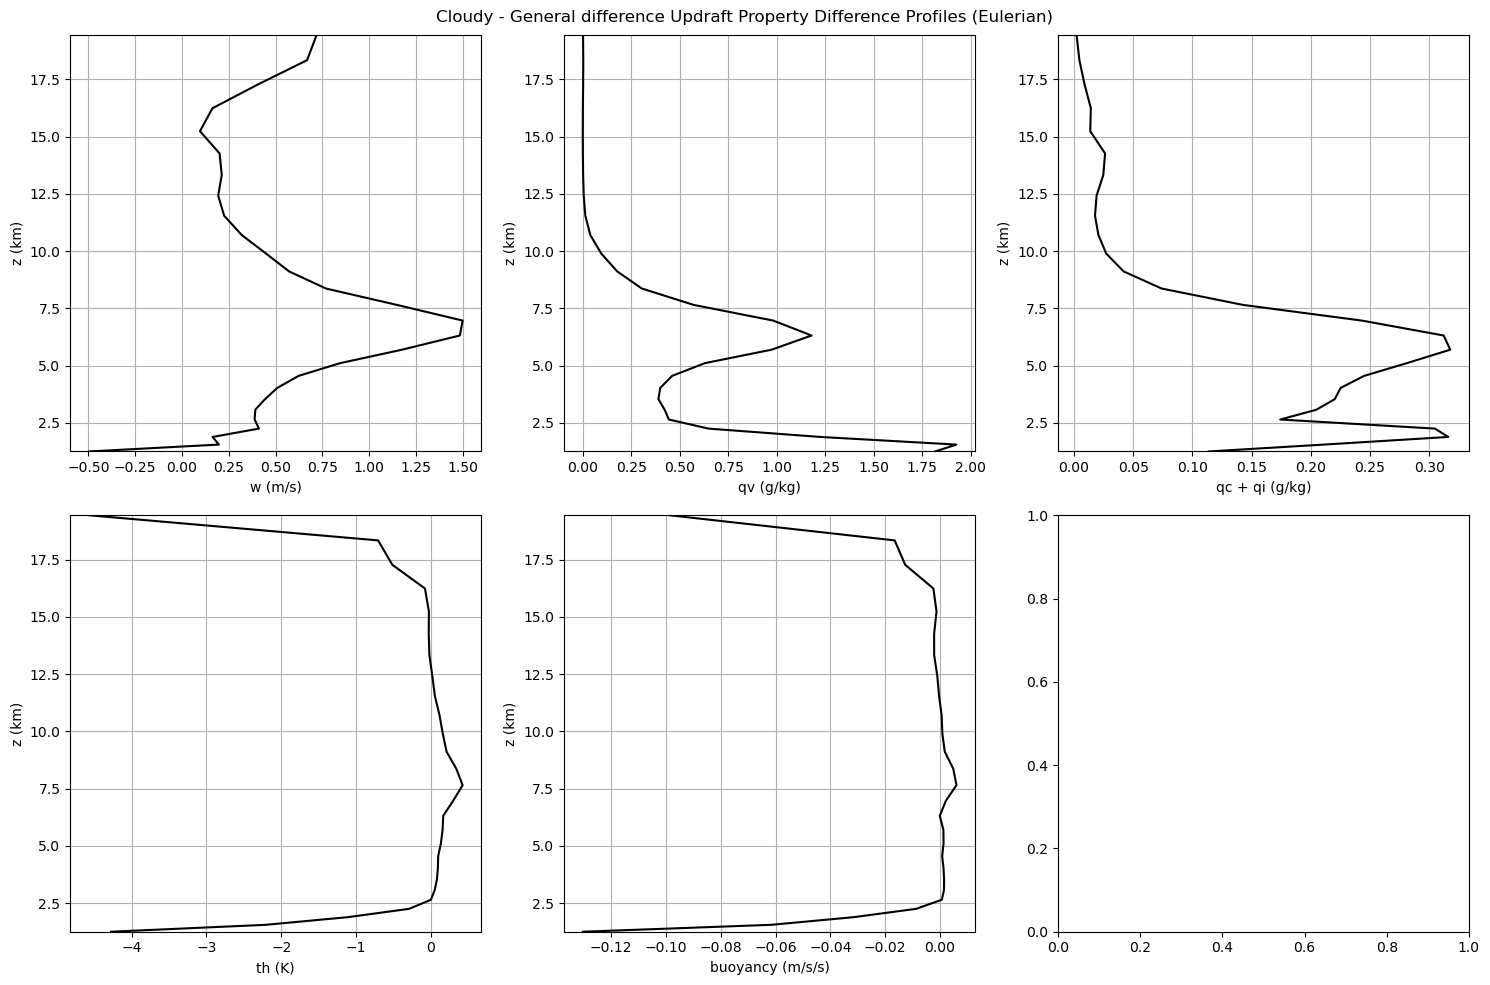

In [17]:
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

    
def get_data(type):
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_wthresh{w_thresh}.h5'
            # input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_wthresh{w_thresh}.h5'
            # input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
def diff_plotting():
    #setting up figure
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Cloudy - General difference Updraft Property Difference Profiles (Eulerian)")
    ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

    #the plotting
    vars=['w','qv','qc','th','buoyancy']
    xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        if var=='qv':axis=ax2
        if var=='qc':axis=ax3
        if var=='th':axis=ax4
        if var=='buoyancy':axis=ax5

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
       
        #averaging
        out_var_one=averaged_profiles(out_var_one.copy())
        out_var_two=averaged_profiles(out_var_two.copy())

        #masking out non matches
        second_col_one = out_var_one[:, 1]
        second_col_two = out_var_two[:, 1]
        mask_one = np.isin(second_col_one, second_col_two)
        mask_two = np.isin(second_col_two, second_col_one)
        out_var_one = out_var_one.copy()[mask_one]
        out_var_two = out_var_two.copy()[mask_two]
        
        axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k')
        # axis.set_ylim(bottom=0,top=20)
        axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
    plt.tight_layout()
    plt.savefig(dir+f'tracking_algorithms/plots/1km_eulerian_updraft_profiles_diff_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #save plot
    # plt.savefig(dir+'tracking_algorithms/plots/1km_eulerian_updraft_profiles_diff_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300)
diff_plotting() 

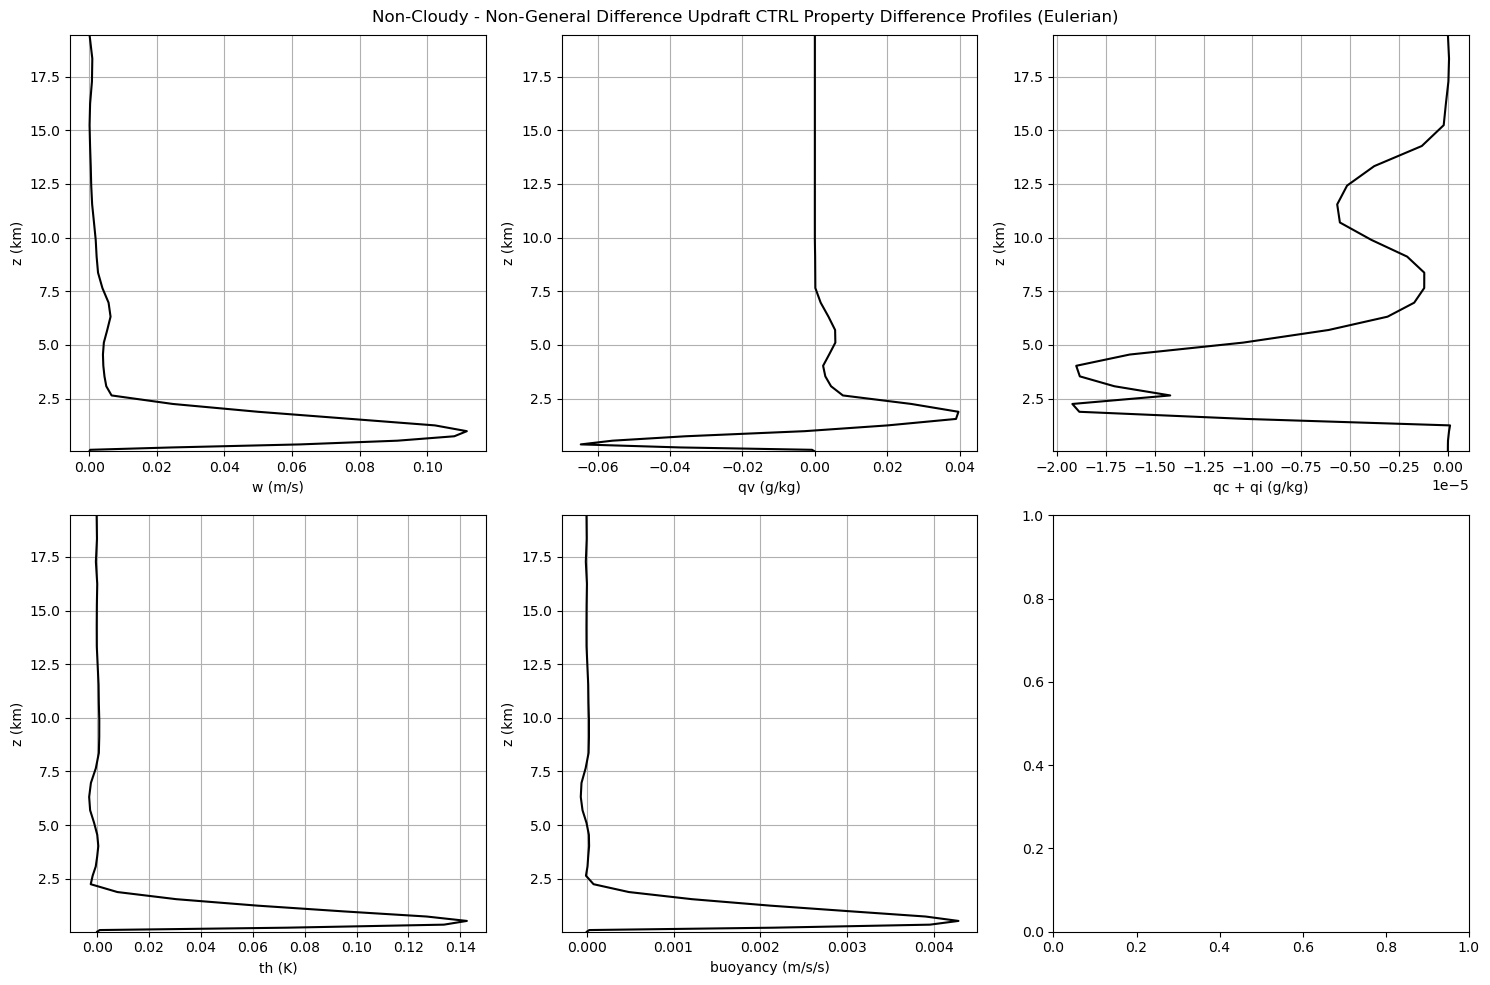

In [35]:
# #Plotting Differences
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

    
# def get_data(type):
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_wthresh{w_thresh}.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
#         globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
#         globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
#         globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
#         globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
#         globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
# def diff_plotting():
#     #setting up figure
#     fig, axs = plt.subplots(2, 3, figsize=(15, 10))
#     fig.suptitle(f"Non-Cloudy - Non-General Difference Updraft CTRL Property Difference Profiles (Eulerian)")
#     ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

#     #the plotting
#     vars=['w','qv','qc','th','buoyancy']
#     xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
#     for xlabel,var in zip(xlabels,vars):
        
#         if var=='w':axis=ax1
#         if var=='qv':axis=ax2
#         if var=='qc':axis=ax3
#         if var=='th':axis=ax4
#         if var=='buoyancy':axis=ax5

#         #get profile
#         types=['cloudy','general']
#         get_data(types[0])
#         out_var_one=globals()[f"{types[0]}_profile_{var}"]
#         get_data(types[1])
#         out_var_two=globals()[f"{types[1]}_profile_{var}"]

#         #finding where cloudy updraft count goes below 10
#         cutofflow=np.where(out_var_one[:,1]>10)[0][0]
#         cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
       
#         #averaging
#         out_var_one=averaged_profiles(out_var_one.copy())
#         out_var_two=averaged_profiles(out_var_two.copy())

#         #masking out non matches
#         second_col_one = out_var_one[:, 1]
#         second_col_two = out_var_two[:, 1]
#         mask_one = np.isin(second_col_one, second_col_two)
#         mask_two = np.isin(second_col_two, second_col_one)
#         out_var_one = out_var_one.copy()[mask_one]
#         out_var_two = out_var_two.copy()[mask_two]
        
#         axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k')
#         # axis.set_ylim(bottom=0,top=20)
#         axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
#         #labeling
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.grid(True)
#         # axis.legend(fontsize='small') #only adds legend at final variable

#         # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
#     plt.tight_layout()
#     plt.savefig(dir+'tracking_algorithms/plots/1km_eulerian_updraft_profiles_diff_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300)
# diff_plotting() 

In [5]:
###########################
# Equivalent Potential Temperature (theta_e)
# surface_prs=data['prs'].mean(dim=("time",'yh','xh')); surface_prs=surface_prs[0]

################################# PRESSURE VARIABLES
p0=101586.6796875 #(x,y,t) averaged surface pressure
P=data['prs'].data

################################# MIXING RATIO
qv=data['qv'].data
qt=(data['qv']+data['qc']+data['qr']+data['qi']+data['qs']+data['qg']).data #total mixing ratio

################################# THERMODYNAMICS
Rd=287
Rv=481
Cpd=1005.7 #+-2.5
Cpv=1870 #+-25
# def Cl(T):***
#     if T>=0+273.15:
#         Cl=4190#+-30
#     elif T<=-40+273.15:
#         Cl= 4770
Cl=4190 #+-30
Lv0=2.501e6
def Lv(T): #Kirchoff's formula L_i,ii= L_i,ii0+(Cpii-Cpi)*(T-273.15)
    Llv=Lv0+(Cpv-Cl)*(T-273.15) #should it be Cpl. is Cl the same?***
    return Llv

################################# TEMPERATURE
theta=data['th'].data
T=theta*(P/p0)**(Rd/Cpd)

################################# RELATIVE HUMIDITY
eps=0.622
#qv=eps*(e/(P-e)) ==> e = qv*P/(eps+qv)
e=qv*P/(qv+eps)
Pd=P-e #P=Pd+e ==> Pd=P-e

e_s0=611
T0=273.15
inner=(Lv(T)/Rv)*((1/T0)-(1/T))
e_s=e_s0*np.exp(inner)
H = e/e_s ########



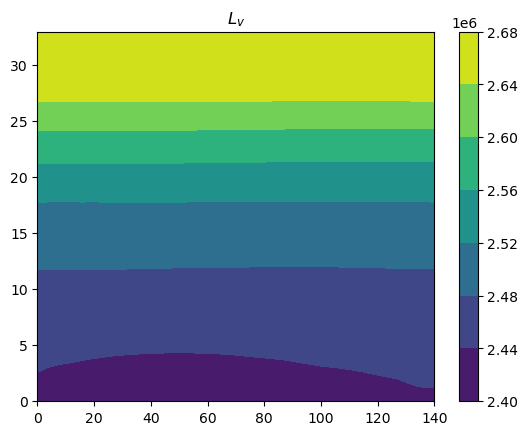

In [91]:
# LV=Lv(T)
# mean=LV.mean(dim=('xh','yh'))
# plt.contourf(mean.T)
# plt.colorbar();
# plt.title(r'$L_v$');

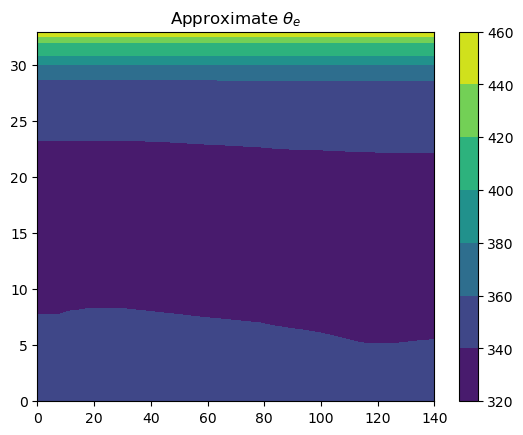

In [35]:
# divisor=(Cpd+Cl*qt)
# theta_e_approx=theta*np.exp(Lv(T)*qv/(divisor*T))
# mean=np.mean(theta_e_approx,axis=(2,3))
# plt.contourf(mean.T)
# plt.colorbar();
# plt.title('Approximate ' + r'$\theta_e$');

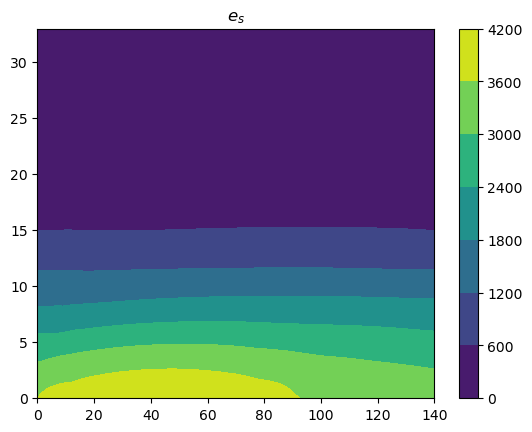

In [11]:
# mean=np.mean(e_s,axis=(2,3))
# plt.contourf(mean.T)
# plt.colorbar();
# plt.title(r'$e_s$');

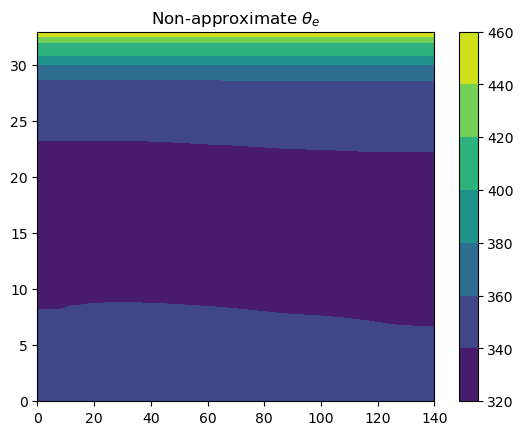

In [14]:
# divisor=(Cpd+Cl*qt)
# theta_e=(T*(p0/Pd)**(Rd/divisor))*(H**(-qv*Rv/divisor))*np.exp(Lv(T)*qv/(divisor*T)) #is Pd==P

# mean=np.mean(theta_e,axis=(2,3))
# plt.contourf(mean.T)
# plt.colorbar();
# plt.title('Non-approximate ' + r'$\theta_e$');

Text(0.5, 1.0, 'comparing non-approximate minus approximate $\\theta_e$')

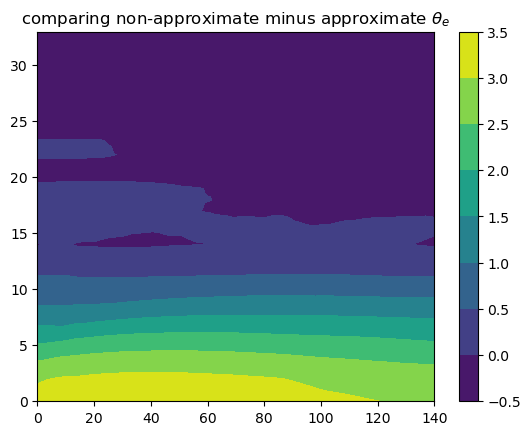

In [82]:
# hey=np.mean((theta_e-theta_e_approx),axis=(2,3))
# plt.contourf(hey.T)
# plt.colorbar()
# plt.title('comparing non-approximate minus approximate ' + r'$\theta_e$')

(320.0, 380.0)

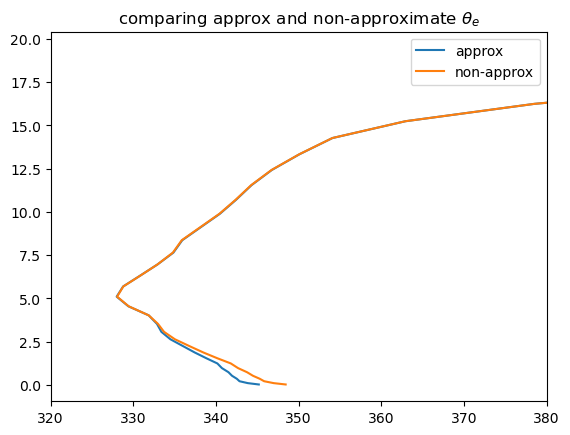

In [80]:
# vert_mean1=np.mean(theta_e_approx,axis=(0,2,3))
# vert_mean2=np.mean(theta_e,axis=(0,2,3))

# plt.plot(vert_mean1,data['zh'],label='approx')
# plt.plot(vert_mean2,data['zh'],label='non-approx')
# plt.legend();
# plt.title('comparing approx and non-approximate ' + r'$\theta_e$') #most difference at the surface 
# #conclusion: use non-approximated version 
# plt.xlim((320,380))

In [52]:
with h5py.File(dir+'theta_e_approx.h5', 'w') as f:
    # Save the array as a variable in the file
    f.create_dataset('theta_e_approx', data=theta_e_approx)

with h5py.File(dir+'theta_e.h5', 'w') as f:
    # Save the array as a variable in the file
    f.create_dataset('theta_e', data=theta_e)

In [83]:
with h5py.File(dir+'theta_e_approx.h5', 'r') as f:
    # Load the dataset by its name
    theta_e_approx = f['theta_e_approx'][:]

with h5py.File(dir+'theta_e.h5', 'r') as f:
    # Load the dataset by its name
    theta_e_data = f['theta_e'][:]

In [84]:
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
def final_profile(var,type):
    global w_thresh
    #thresholds
    w_thresh=1
    qcqithresh=1e-6

    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #gets data associated with threshold mask
    if var=='w':
        masked_data=w_data[where_updraft]
    if var=='qv':
        masked_data=qv_data[where_updraft]
    if var=='qc':
        masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
    if var=='qi':
        masked_data=qi_data[where_updraft]
    if var=='th':
        masked_data=th_data[where_updraft]
    if var=='buoyancy':
        masked_data=buoyancy_data[where_updraft]
    if var=='theta_e':
        masked_data=theta_e_data[where_updraft]
    if var=='theta_e_test':
        masked_data=theta_e_approx[where_updraft]
        
    #converts qv and qc from kg/kg=>g/kg
    if var in ['qv','qc','qi']:
        masked_data*=1000

    #bin masked values by z level
    for (kh,value) in zip(z_ind,masked_data):
        profile_array[kh,0]+=value #adds data to first column
        profile_array[kh,1]+=1 #adds +1 counter to 2nd column
    return profile_array

In [85]:
x1=final_profile('theta_e','general')
x2=final_profile('theta_e','cloudy')

x3=final_profile('theta_e_test','general')
x4=final_profile('theta_e_test','cloudy')

(330.0, 380.0)

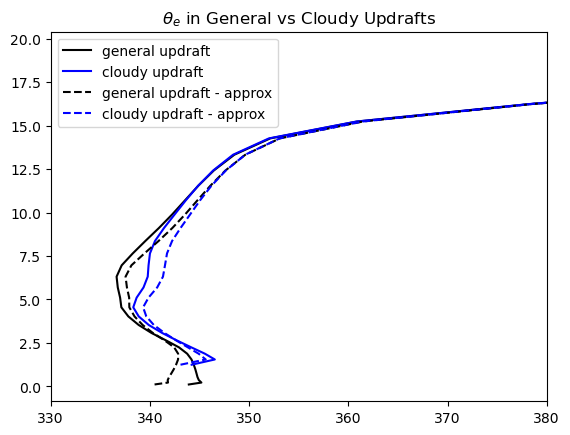

In [86]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

x1_avg=averaged_profiles(x1)
x2_avg=averaged_profiles(x2)

plt.plot(x1_avg[:,0],x1_avg[:,1],label='general updraft',color='k')
plt.plot(x2_avg[:,0],x2_avg[:,1],label='cloudy updraft',color='blue')
plt.legend();


plt.plot(x3_avg[:,0],x3_avg[:,1],label='general updraft - approx',color='k',linestyle='dashed')
plt.plot(x4_avg[:,0],x4_avg[:,1],label='cloudy updraft - approx',color='b',linestyle='dashed')
plt.legend();
plt.title(r'$\theta_e$'+' in General vs Cloudy Updrafts')

plt.xlim((330,380))